<a href="https://colab.research.google.com/github/muhammad-rhakan/summer-project/blob/main/Workspace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Preliminaries

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import (
    Layer,
    Conv1D, MaxPooling1D, UpSampling1D, LayerNormalization, Dropout,
    GRU, LSTM, Dense,
    Flatten, Reshape, RepeatVector, TimeDistributed)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader

In [ ]:
def implement_basic_cleaning(data):
    # Fix titles
    data.columns = data.columns.str.strip()

    # Repair time format and set index
    data['Timestamp'] = data['Timestamp'].str.strip()
    data['Timestamp'] = pd.to_datetime(data['Timestamp'], format='%d/%m/%Y %I:%M:%S %p')
    data = data.sort_values('Timestamp', ascending=True)
    data = data.drop_duplicates().dropna()
    data = data.reset_index(drop=True)

    # Encode target feature
    target = 'Normal/Attack'
    data[target] = data[target].map({'Normal':0, 'Attack':1})

    return data

# Execude function
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "vishala28/swat-dataset-secure-water-treatment-system","merged.csv")
data_complete = implement_basic_cleaning(df)

/tmp/ipykernel_2366/2182073669.py:19: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "vishala28/swat-dataset-secure-water-treatment-system","merged.csv")


Using Colab cache for faster access to the 'swat-dataset-secure-water-treatment-system' dataset.


In [ ]:
X = data_complete.drop(columns={'Timestamp', 'Normal/Attack'})
y = data_complete.iloc[:,-1:]

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

## Sequential Modeling Base

In [ ]:
SAMPLES, FEATURES = X.shape
TIME_STEPS = 96
BATCH_SIZE = 512

train, val = int(SAMPLES * 0.7), int(SAMPLES * 0.15)

X_train = matrix[:train]
X_val = matrix[train:train + val]
X_test = matrix[train + val:]


train_input_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=X_train,
    targets=None,
    sequence_length=TIME_STEPS,
    batch_size=BATCH_SIZE,
    shuffle=False)

val_input_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=X_val,
    targets=None,
    sequence_length=TIME_STEPS,
    batch_size=BATCH_SIZE,
    shuffle=False)

predict_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=X_test,
    targets=None,
    sequence_length=TIME_STEPS,
    batch_size=BATCH_SIZE,
    shuffle=False)

def set_shape(x):
    x.set_shape([None, TIME_STEPS, FEATURES])
    return x, x

train_ds = train_input_ds.map(set_shape).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_input_ds.map(set_shape).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = predict_ds.map(set_shape).prefetch(buffer_size=tf.data.AUTOTUNE)

### LSTM Autoencoder

In [ ]:
class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


class LSTM_VAE(tf.keras.Model):
    def __init__(self, time_steps, features, latent_dim, dropout):
        super().__init__()

        self.encoder = Sequential([
            LSTM(units=64, return_sequences=True, input_shape=(time_steps, features)),
            LayerNormalization(),
            Dropout(dropout),
            LSTM(units=32, return_sequences=True),
            LayerNormalization(),
            Dropout(dropout),
            LSTM(units=16, return_sequences=False)
        ])

        self.get_mean = Dense(latent_dim, name='z_mean')
        self.get_log_var = Dense(latent_dim, name='z_log_var')

        self.sampling = Sampling()
        self.z_space = RepeatVector(time_steps)

        self.decoder = Sequential([
            LSTM(units=latent_dim, return_sequences=True, input_shape=(time_steps, latent_dim)),
            LayerNormalization(),
            Dropout(dropout),
            LSTM(units=32, return_sequences=True),
            LayerNormalization(),
            Dropout(dropout),
            LSTM(units=64, return_sequences=True),
            TimeDistributed(Dense(features))
        ])


    def call(self, X):
        h = self.encoder(X)

        z_mean = self.get_mean(h)
        z_log_var = self.get_log_var(h)
        z = self.sampling([z_mean, z_log_var])
        z_copy = self.z_space(z)

        y = self.decoder(z_copy)

        return y, z_mean, z_log_var


    def train_step(self, data):
        if isinstance(data, tuple):
            x, _ = data
        else:
            x = data

        with tf.GradientTape() as tape:
            y_pred, z_mean, z_log_var = self(x, training=True)

            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - y_pred), axis=[1, 2]))
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return total_loss


    def test_step(self, data):
        if isinstance(data, tuple):
            x, _ = data
        else:
            x = data

        y_pred, z_mean, z_log_var = self(x, training=False)

        reconstruction_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - y_pred), axis=[1, 2]))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1))
        total_loss = reconstruction_loss + kl_loss

        return total_loss


model = LSTM_VAE(time_steps=TIME_STEPS,
               features=FEATURES,
               latent_dim=8,
               dropout=0.2)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

checkpoint_path_lstm = "checkpoints_lstm/model_epoch_{epoch:02d}_val_loss_{val_loss:.4f}.weights.h5"
checkpoint_lstm = ModelCheckpoint(
    filepath=checkpoint_path_lstm,
    monitor='val_loss',
    save_best_only=True,      # Saves only when validation loss improves
    mode='min',
    save_weights_only=True,  # Saves the entire model architecture + weights
    verbose=1)
stoppage = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    patience=5,
    verbose=1)


history = model.fit(train_ds,
                    epochs=50,
                    verbose=1,
                    validation_data=val_ds,
                    callbacks=[stoppage, lr_scheduler, checkpoint_lstm],
                    shuffle=False)

print("Training complete! Final Loss:", history.history['loss'][-1])

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - kl_loss: 5.4637 - loss: 2152.3074 - reconstruction_loss: 2146.8433
Epoch 1: val_loss improved from None to 2495.46582, saving model to checkpoints_lstm/model_epoch_01_val_loss_2495.4658.weights.h5

Epoch 1: finished saving model to checkpoints_lstm/model_epoch_01_val_loss_2495.4658.weights.h5
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 149s 98ms/step - kl_loss: 7.1858 - loss: 1087.8954 - reconstruction_loss: 1080.7100 - val_kl_loss: 6.9565 - val_loss: 2495.4658 - val_reconstruction_loss: 2488.5095 - learning_rate: 0.0010
Epoch 2/50
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - kl_loss: 10.0215 - loss: 2072.6512 - reconstruction_loss: 2062.6304
Epoch 2: val_loss improved from 2495.46582 to 2439.75195, saving model to checkpoints_lstm/model_epoch_02_val_loss_2439.7520.weights.h5

Epoch 2: finished saving model to checkpoints_lstm/model_epoch_02_val_loss_2439.7520.weights.h5
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 134s 97ms/step - kl_loss: 9.4015 - loss: 1026.2699 

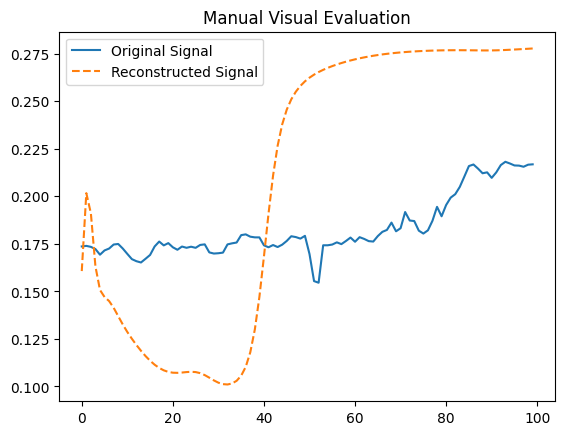

Mean Absolute Error for this batch: 0.43988365


In [ ]:
for X_test in predict_ds.take(1):
    reconstructed, z_mean, z_log_var = model(X_test, training=False)

    X_test_np = X_test.numpy()
    reconstructed_np = reconstructed.numpy()

    plt.plot(X_test_np[0, :, 0], label="Original Signal")
    plt.plot(reconstructed_np[0, :, 0], label="Reconstructed Signal", linestyle="--")
    plt.legend()
    plt.title("Manual Visual Evaluation")
    plt.show()

    mae_dist = tf.keras.losses.MAE(X_test, reconstructed)
    print("Mean Absolute Error for this batch:", tf.reduce_mean(mae_dist).numpy())

    break

### TCN Autoencoder

In [ ]:
class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim), dtype=z_mean.dtype)

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


class TCN_AE(tf.keras.Model):
    def __init__(self, time_steps, features, latent_dim):
        super().__init__()

        self.time_steps = time_steps
        self.features = features
        self.latent_dim = latent_dim

        self.encoder = Sequential([
            Conv1D(filters=64, kernel_size=3, padding='causal', activation='relu', input_shape=(time_steps, features)),
            MaxPooling1D(pool_size=2),
            Conv1D(filters=32, kernel_size=3, padding='causal', activation='relu', dilation_rate=2),
            MaxPooling1D(pool_size=2),
            Conv1D(filters=16, kernel_size=3, padding='causal', activation='relu', dilation_rate=4),
            MaxPooling1D(pool_size=2),
            Flatten()
        ])

        self.get_mean = Dense(latent_dim, name='z_mean')
        self.get_log_var = Dense(latent_dim, name='z_log_var')
        self.sampling = Sampling()

        self.encoded_time_steps = time_steps // 8
        self.encoded_filters = 16

        self.decoder_input = Dense(self.encoded_time_steps * self.encoded_filters, activation='relu')
        self.reshape_layer = Reshape((self.encoded_time_steps, self.encoded_filters))


        self.decoder = Sequential([
            UpSampling1D(size=2),
            Conv1D(filters=16, kernel_size=3, padding='causal', activation='relu'),
            UpSampling1D(size=2),
            Conv1D(filters=32, kernel_size=3, padding='causal', activation='relu'),
            UpSampling1D(size=2),
            Conv1D(filters=64, kernel_size=3, padding='causal', activation='relu'),
            Conv1D(filters=features, kernel_size=3, activation='linear', padding='same')
        ])


    def call(self, X):
        h = self.encoder(X)
        z_mean = self.get_mean(h)
        z_log_var = self.get_log_var(h)

        # kl_loss = -0.5 * tf.reduce_mean(z_log_var - tf.square(z_mean) - tf.exp(z_log_var) + 1)
        kl_loss = -0.5 * tf.reduce_mean(
            tf.cast(z_log_var, tf.float32)
            - tf.square(tf.cast(z_mean, tf.float32))
            - tf.exp(tf.cast(z_log_var, tf.float32))
            + 1)

        self.add_loss(kl_loss)

        z = self.sampling([z_mean, z_log_var])

        x_decoded = self.decoder_input(z)
        x_decoded = self.reshape_layer(x_decoded)

        y = self.decoder(x_decoded)
        return y

In [ ]:
model = TCN_AE(
    time_steps=TIME_STEPS,
    features=FEATURES,
    latent_dim=8)
model.build(input_shape=(None, TIME_STEPS, FEATURES))
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

checkpoint_path_cnn = "checkpoints/model_epoch_{epoch:02d}_val_loss_{val_loss:.4f}.weights.h5"
checkpoint_cnn = ModelCheckpoint(
    filepath=checkpoint_path_cnn,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    save_weights_only=True,
    verbose=1)
stoppage = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1)


history = model.fit(
    train_ds,
    epochs=10,
    verbose=1,
    validation_data=val_ds,
    callbacks=[stoppage, lr_scheduler, checkpoint_cnn],
    shuffle=False # Note: If using tf.data.Dataset, shuffling is handled inside the pipeline above
)

print("Training complete! Final Loss:", history.history['loss'][-1])